In [6]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.model import load_model
import json, joblib

model      = load_model(PROJECT_ROOT / 'models' / 'xgb_model.pkl')
feat_names = json.load(open(PROJECT_ROOT / 'models' / 'feature_names.json'))

# Use TreeExplainer for exact SHAP values for XGBoost
explainer = shap.TreeExplainer(model)
joblib.dump(explainer, PROJECT_ROOT / 'models' / 'shap_explainer.pkl')
print('Explainer saved.')


Explainer saved.


In [7]:
# Rebuild X_test in this notebook
import importlib
import src.preprocess
importlib.reload(src.preprocess)
from src.preprocess import load_raw, engineer_features, encode_and_split

raw        = load_raw(PROJECT_ROOT / 'data' / 'DataCoSupplyChainDataset.csv')
engineered = engineer_features(raw)

X_train, X_test, y_train, y_test, feat_names, encoders = encode_and_split(
    engineered, target_col='Late_delivery_risk', test_year=2017
)

print(f'X_test shape: {X_test.shape}')


X_test shape: (55319, 37)


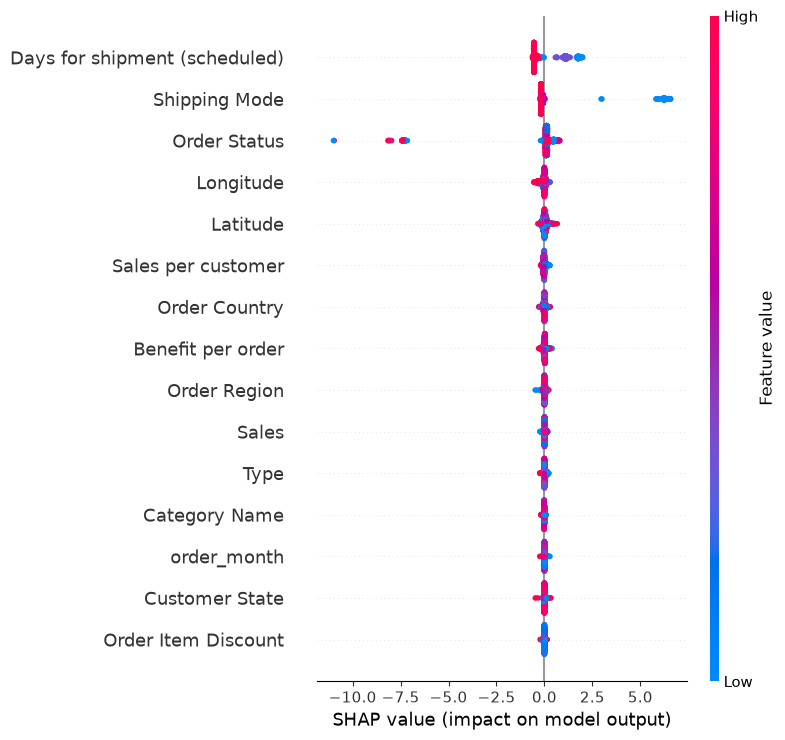

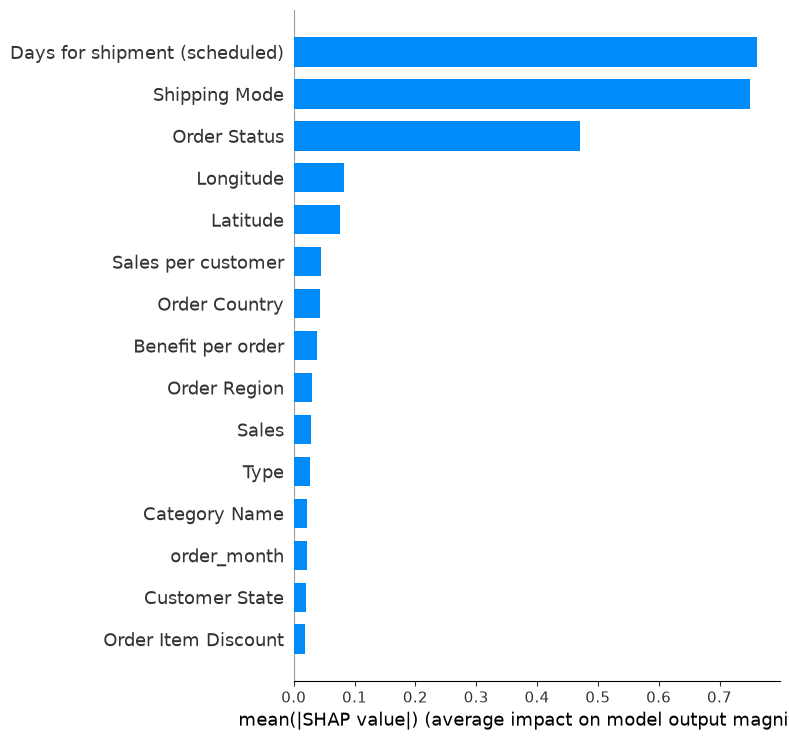

In [8]:
X_test_df = pd.DataFrame(X_test[:2000], columns=feat_names)
shap_test  = explainer.shap_values(X_test_df)

# Beeswarm
shap.summary_plot(shap_test, X_test_df, max_display=15, show=False)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar
shap.summary_plot(shap_test, X_test_df, plot_type='bar', max_display=15, show=False)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()


In [9]:
# This is what Streamlit runs for individual order risk explanation
idx          = 0
single_order = pd.DataFrame(X_test[[idx]], columns=feat_names)
single_shap  = explainer.shap_values(single_order)[0]

top3_idx = np.argsort(np.abs(single_shap))[::-1][:3]
print('Top 3 risk drivers for this order:')
for i in top3_idx:
    direction = 'INCREASES' if single_shap[i] > 0 else 'DECREASES'
    print(f'  {feat_names[i]}: {direction} risk by {abs(single_shap[i]):.3f}')


Top 3 risk drivers for this order:
  Days for shipment (scheduled): DECREASES risk by 0.532
  Longitude: DECREASES risk by 0.320
  Shipping Mode: DECREASES risk by 0.181
